# Pedestal density height from an `SC_1D_Snyder.py` scan

Reads a scan directory written by `SC_1D_Snyder.py` (e.g. `Snyder_firedrake_inner`,
`Snyder_scipy_outer`) and plots simulated vs experimental pedestal electron density,
using the same method as the density-scan grid in
`examples/device_prediction/DIII-D/plot_scan_SCfp_ESCAPE.ipynb`.

**How the pedestal height is selected.** `SC_1D_Snyder.py` saves the solved profile as
`x_sol` [m, 0 at the separatrix] and `ne_sol` [m^-3] rather than the `profiles_solved`
psi_N grid the ESCAPE scan writes, so the simulated pedestal height is read as
`ne_sol[0]`, the first element of the solved profile. `x_sol` is ascending from `x_inner` to 0 at the
separatrix, so element 0 *is* `psi_N_inner` (0.85 in `SC_1D_Snyder.py`), the solver's
inner boundary, which is exactly the psi_N the ESCAPE
notebook reads both densities at. The experimental value is interpolated from
`out_dict['profiles']` at the same psi_N.

**Panel layout.** `SC_1D_Snyder.py` scans `alpha_crit`, `C_KBM`, `De_chie_etg` and
`nFC_x0` (it has no `ncx_x0_ratio`, which is the ESCAPE scan's column variable), so
`C_KBM` takes the column axis: one figure per `alpha_crit`, one row per `nFC_x0`, one
column per `C_KBM`, colours = `D/chi` with the RMSE in the legend.

In [24]:
# --- Load one SC_1D_Snyder.py scan directory ---------------------------------
# Directory layout written by SC_1D_Snyder.py:
#   {SCAN_DIR}/{equil_tag}/fp{i}/out_dict.npy   (or failed.npy on an exception)
# out_dict carries:
#   'profiles'    experimental input profiles, 'ne' [m^-3] on 'psi_N_ne'
#   'x_sol'       solved radial grid [m], 0 at the separatrix, x_sol.min() = psi_N_inner
#   'ne_sol'      solved electron density [m^-3] on x_sol
#   'free_params' alpha_crit, C_KBM, De_chie_etg, nFC_x0
# Runs still in flight (neither out_dict.npy nor failed.npy) are counted as `pending`,
# so this can be re-run while a scan is still writing equilibria.

from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

# ------------------------------------------------------------------ user input
SCAN_DIR = Path('Snyder_scipy_inner')   # any SC_1D_Snyder.py output directory
# psi_N at which both densities are read. This must equal the psi_N_inner used in
# SC_1D_Snyder.py: the simulated value is taken at the solver's inner boundary, which
# is the innermost point of the solved profile, and there is no solved density inboard
# of it. Change it only if you changed psi_N_inner in the scan.
PSI_NE = 0.85
AXIS_MAX = 11               # axis limit in 10^19 m^-3, as in the reference figures
# D/chi colours in legend order; None assigns them automatically from the scan
DETG_COLORS = None
# Figure / row / column order; None takes every value present in the scan, ascending
CASES = None                # one figure per alpha_crit
NFC_X0S = None              # rows
C_KBMS = None               # columns
# -----------------------------------------------------------------------------

_DEFAULT_DETG_COLORS = ['silver', 'red', 'tab:blue', 'tab:green',
                        'tab:orange', 'tab:purple']


def _ne_at(psi_src, ne_src, psi_N):
    """Electron density [m^-3] at psi_N, or NaN if psi_N is off the grid."""
    psi_src = np.asarray(psi_src, dtype=float)
    ne_src = np.asarray(ne_src, dtype=float)
    if psi_N < psi_src.min() or psi_N > psi_src.max():
        return np.nan
    order = np.argsort(psi_src)
    return float(np.interp(psi_N, psi_src[order], ne_src[order]))


def _ne_ped_sim(out_dict):
    """Simulated pedestal density [m^-3]: n_e at psi_N = PSI_NE.

    SC_1D_Snyder.py stores the solved profile on x_sol [m], ascending from
    x_inner (< 0) to 0 at the separatrix, so element 0 is the solver's inner
    boundary and there is no solved density inboard of it. That point is exactly
    the x of psi_N = psi_N_inner: checked against the equilibrium for a sample
    case, x_sol[0] = -0.047106 m = interp(0.85, psi_N_pres, x_init) to 0.0 m, and
    x_sol is ascending in all 1172 runs of the four Snyder_* scans. So ne_sol[0]
    is n_e at psi_N = 0.85, the same psi_N the experimental density is read at.
    """
    x = np.asarray(out_dict['x_sol'], dtype=float)
    ne = np.asarray(out_dict['ne_sol'], dtype=float)
    if x.size == 0 or ne.size != x.size:
        return np.nan
    if x[0] != x.min():
        raise ValueError(
            'x_sol is not ascending, so ne_sol[0] is not the inner boundary; '
            'the pedestal height would be read at the wrong end of the profile')
    return float(ne[0])


def load_scan(scan_dir, psi_ne=PSI_NE):
    """Experimental and simulated n_e,ped for every finished run of the scan.

    Returns (runs, failed, pending, outside, n_equil_total); densities are in
    10^19 m^-3, and a run whose experimental profile does not reach psi_ne lands
    in `outside`. n_equil_total is the number of equilibrium directories in the
    scan, i.e. the denominator for "how many equilibria found a solution".
    """
    scan_dir = Path(scan_dir)
    runs, failed, pending, outside = [], [], [], []
    equil_dirs = sorted(p for p in scan_dir.iterdir() if p.is_dir())
    for equil_dir in equil_dirs:
        for run_dir in sorted(equil_dir.glob('fp*'),
                              key=lambda p: int(p.name[2:])):
            name = f'{equil_dir.name}/{run_dir.name}'
            out_fp = run_dir / 'out_dict.npy'
            if not out_fp.exists():
                (failed if (run_dir / 'failed.npy').exists()
                 else pending).append(name)
                continue
            d = np.load(out_fp, allow_pickle=True).item()
            ne_sim = _ne_ped_sim(d)
            ne_exp = _ne_at(d['profiles']['psi_N_ne'], d['profiles']['ne'], psi_ne)
            if not (np.isfinite(ne_sim) and np.isfinite(ne_exp)):
                outside.append(name)
                continue
            fp = d['free_params']
            runs.append({
                'equil':      equil_dir.name,
                'run':        run_dir.name,
                'alpha_crit': float(fp['alpha_crit']),
                'C_KBM':      float(fp['C_KBM']),
                'detg':       float(fp['De_chie_etg']),
                'nFC_x0':     float(fp['nFC_x0']),
                'ne_sim':     ne_sim / 1e19,     # m^-3 -> 10^19 m^-3
                'ne_exp':     ne_exp / 1e19,
            })
    return runs, failed, pending, outside, len(equil_dirs)


def detg_color_map(runs):
    """D/chi -> colour, honouring DETG_COLORS when the user has set it."""
    if DETG_COLORS is not None:
        return dict(DETG_COLORS)
    vals = sorted({r['detg'] for r in runs})
    return {v: _DEFAULT_DETG_COLORS[i % len(_DEFAULT_DETG_COLORS)]
            for i, v in enumerate(vals)}


if not SCAN_DIR.is_dir():
    raise FileNotFoundError(f'{SCAN_DIR} not found; set SCAN_DIR to a scan directory '
                            'written by SC_1D_Snyder.py')

scan_runs, scan_failed, scan_pending, scan_outside, N_EQUIL_TOTAL = load_scan(SCAN_DIR)
N_EQUIL_OK = len({r['equil'] for r in scan_runs})
print(f'[{SCAN_DIR.name}] successful {len(scan_runs)}, failed {len(scan_failed)}, '
      f'pending {len(scan_pending)}, outside the experimental grid {len(scan_outside)}')
print(f'  {N_EQUIL_OK}/{N_EQUIL_TOTAL} equilibria found a solution')
if scan_runs:
    sim = np.array([r['ne_sim'] for r in scan_runs])
    exp = np.array([r['ne_exp'] for r in scan_runs])
    rmse = np.sqrt(np.mean(((sim - exp) / exp) ** 2)) * 100
    print(f'  n_e,ped at psi_N = {PSI_NE:g}')
    print(f'    simulated    {sim.min():.2f} .. {sim.max():.2f} x10^19 m^-3')
    print(f'    experimental {exp.min():.2f} .. {exp.max():.2f} x10^19 m^-3')
    print(f'    overall RMSE {rmse:.1f}%')
    print(f'  free parameters present: '
          f"alpha_crit={sorted({r['alpha_crit'] for r in scan_runs})}, "
          f"C_KBM={sorted({r['C_KBM'] for r in scan_runs})}, "
          f"De_chie_etg={sorted({r['detg'] for r in scan_runs})}, "
          f"nFC_x0={[f'{v:.3g}' for v in sorted({r['nFC_x0'] for r in scan_runs})]}")

[Snyder_scipy_inner] successful 284, failed 18, pending 0, outside the experimental grid 0
  284/302 equilibria found a solution
  n_e,ped at psi_N = 0.85
    simulated    1.16 .. 11.32 x10^19 m^-3
    experimental 1.52 .. 8.18 x10^19 m^-3
    overall RMSE 37.3%
  free parameters present: alpha_crit=[0.01], C_KBM=[0.3], De_chie_etg=[0.1], nFC_x0=['1e+15']


  alpha_crit = 0.01: 284 runs over 284 equilibria, rows (nFC_x0) = ['1e+15'], columns (C_KBM) = ['0.3']


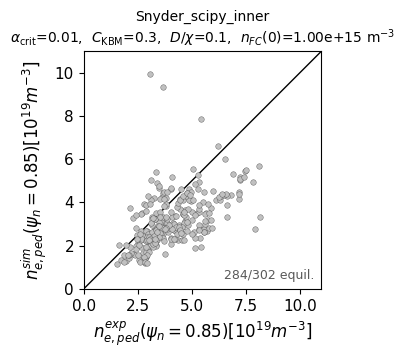

In [25]:
# --- n_e,ped grids over the scan: nFC(0) x C_KBM, one figure per alpha_crit ---
# Simulated vs experimental pedestal electron density at psi_N = PSI_NE, colours =
# D/chi with the RMSE in the legend, y = x drawn for perfect prediction. Same layout
# and styling as the ESCAPE density-scan grid, with C_KBM on the column axis in place
# of that scan's nCX(0)/nFC(0).

def plot_ne_ped_grid(runs, alpha_crit, colors):
    """One nFC(0) x C_KBM figure at fixed alpha_crit."""
    case = [r for r in runs if np.isclose(r['alpha_crit'], alpha_crit)]
    if not case:
        print(f'  alpha_crit = {alpha_crit:g}: no runs, skipped')
        return

    rows = (sorted({r['nFC_x0'] for r in case})
            if NFC_X0S is None else list(NFC_X0S))
    cols = (sorted({r['C_KBM'] for r in case})
            if C_KBMS is None else list(C_KBMS))
    n_eq = len({r['equil'] for r in case})
    print(f'  alpha_crit = {alpha_crit:g}: {len(case)} runs over {n_eq} equilibria, '
          f'rows (nFC_x0) = {[f"{v:.3g}" for v in rows]}, '
          f'columns (C_KBM) = {[f"{v:g}" for v in cols]}')

    fig, axes = plt.subplots(figsize=(5,4))

    for i_row, nFC_x0 in enumerate(rows):
        for i_col, C_KBM in enumerate(cols):
            ax = axes
            cell = [r for r in case
                    if np.isclose(r['nFC_x0'], nFC_x0)
                    and np.isclose(r['C_KBM'], C_KBM)]

            # perfect prediction, drawn first so the points sit on top
            ax.plot([0, AXIS_MAX], [0, AXIS_MAX], color='k', linewidth=1.0, zorder=0)

            for detg, color in colors.items():
                g = [r for r in cell if np.isclose(r['detg'], detg)]
                if not g:
                    continue
                ne_exp = np.array([r['ne_exp'] for r in g])
                ne_sim = np.array([r['ne_sim'] for r in g])
                # RMSE relative to the experimental density, as in the captions
                rmse = np.sqrt(np.mean(((ne_sim - ne_exp) / ne_exp) ** 2)) * 100
                ax.plot(ne_exp, ne_sim, 'o', color=color, markersize=4,
                        markeredgecolor='0.35', markeredgewidth=0.3,
                        linestyle='none',
                        label=rf'$D/\chi$={detg:g} ({rmse:.0f}%)')

            ax.set_xlim(0, AXIS_MAX)
            ax.set_ylim(0, AXIS_MAX)
            ax.set_aspect('equal', adjustable='box')
            ax.tick_params(axis='both', labelsize=11)
            if ax.get_legend_handles_labels()[0]:
                # ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
                # how many equilibria converged in this panel
                ax.text(0.97, 0.03, f'{len({r["equil"] for r in cell})}/'
                        f'{N_EQUIL_TOTAL} equil.', transform=ax.transAxes,
                        ha='right', va='bottom', fontsize=9, color='0.35')
            else:
                ax.text(0.5, 0.5, 'no runs', transform=ax.transAxes,
                        ha='center', va='center', fontsize=11, color='0.5')
            if i_row == len(rows) - 1:
                ax.set_xlabel(r'$n_{e,ped}^{exp}(\psi_n=0.85)[10^{19} m^{-3}]$', fontsize=12)
            if i_col == 0:
                ax.set_ylabel(r'$n_{e,ped}^{sim}(\psi_n=0.85)[10^{19} m^{-3}]$', fontsize=12)

    # Second title row: the free-parameter values actually drawn in this figure.
    # Each is a set rather than a scalar, so a scan with several values of one
    # parameter still reports honestly (they are joined with commas) instead of
    # silently showing only the last one.
    plotted = [r for r in case
               if any(np.isclose(r['nFC_x0'], v) for v in rows)
               and any(np.isclose(r['C_KBM'], v) for v in cols)]

    def _fmt(values, spec='g'):
        return ', '.join(f'{v:{spec}}' for v in sorted(set(values)))

    axes.set_title(f'{SCAN_DIR.name}'
                   '\n'
                   rf'$\alpha_{{\rm crit}}$={_fmt(r["alpha_crit"] for r in plotted)},  '
                   rf'$C_{{\rm KBM}}$={_fmt(r["C_KBM"] for r in plotted)},  '
                   rf'$D/\chi$={_fmt(r["detg"] for r in plotted)},  '
                   rf'$n_{{FC}}(0)$={_fmt((r["nFC_x0"] for r in plotted), ".2e")}'
                   r' m$^{-3}$',
                   fontsize=10)
    fig.tight_layout(rect=(0, 0, 1, 0.92))
    plt.show()


if not scan_runs:
    print('no finished runs yet, nothing to plot')
else:
    DETG_MAP = detg_color_map(scan_runs)
    cases = (sorted({r['alpha_crit'] for r in scan_runs})
             if CASES is None else list(CASES))
    for alpha_crit in cases:
        plot_ne_ped_grid(scan_runs, alpha_crit, DETG_MAP)